<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/projects/Projects/McLarty_Project2_BipartiteNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Drug–Side Effect Bipartite Network Analysis

**Course:** DATA 620 – Web Analytics, Spring 2026  
**School:** CUNY School of Professional Studies  
**Student:** Sheriann McLarty  

**Dataset:** Drug–Side Effect Association Network (SIDER 4.1)  
**Source:** Stanford BioSNAP — https://snap.stanford.edu/biodata/datasets/10018/  
**Network:** 640 drug nodes | 10,185 side effect nodes | 174,977 edges  

**Citations:**  
Zitnik, Agrawal & Leskovec. Modeling polypharmacy side effects with graph convolutional networks. *Bioinformatics*, 2018.  
Kuhn et al. The SIDER database of drugs and side effects. *Nucleic Acids Research*, 2015.


## Why This Dataset

*I chose this dataset because opioid-related drugs are commonly used in overdose treatment across the shelter system — both at the facility level and statewide. I wanted to see what side effects these drugs share and whether the data reflected anything about how effective they are when interacting with other opioids in a clinical context.*


## Research Question

How are opioid-related drugs positioned within a drug–side effect bipartite network, and what does the shared side-effect structure reveal after reducing the network using the island method?


In [1]:
# ============================================================
# CELL 1: Load raw data and confirm bipartite structure
# ============================================================

# WHY THIS CELL EXISTS:
# Before building any graph we verify the raw data has a true
# 2-node structure: drugs on one side, side effects on the other,
# with NO within-group ties.

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests
import time

URL = "https://snap.stanford.edu/biodata/datasets/10018/files/ChSe-Decagon_monopharmacy.csv.gz"
df = pd.read_csv(URL, compression='gzip')

print("=== RAW DATA SHAPE ===")
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()
print("=== FIRST 5 ROWS ===")
print(df.head())

=== RAW DATA SHAPE ===
Rows: 174,977
Columns: ['# STITCH', 'Individual Side Effect', 'Side Effect Name']

=== FIRST 5 ROWS ===
       # STITCH Individual Side Effect                Side Effect Name
0  CID003062316               C1096328     central nervous system mass
1  CID003062316               C0162830       Photosensitivity reaction
2  CID003062316               C1611725    leukaemic infiltration brain
3  CID003062316               C0541767  platelet adhesiveness abnormal
4  CID003062316               C0242973         Ventricular dysfunction


In [2]:
# ============================================================
# CELL 2: Clean columns and confirm structure
# ============================================================

# WHY THIS CELL EXISTS:
# The raw column names have special characters. We rename them
# cleanly and confirm the two-node bipartite structure holds.

df.columns = ['drug_id', 'se_id', 'se_name']

n_drugs = df['drug_id'].nunique()
n_se    = df['se_id'].nunique()
overlap = set(df['drug_id']) & set(df['se_id'])

print("=== BIPARTITE STRUCTURE CONFIRMATION ===")
print(f"Unique drugs (STITCH IDs):        {n_drugs:,}")
print(f"Unique side effects (UMLS terms): {n_se:,}")
print(f"Total pairs:                      {len(df):,}")
print(f"Overlap between groups (must=0):  {len(overlap)}")
print()
print("=== SAMPLE SIDE EFFECT NAMES ===")
print(df['se_name'].value_counts().head(15).to_string())

=== BIPARTITE STRUCTURE CONFIRMATION ===
Unique drugs (STITCH IDs):        639
Unique side effects (UMLS terms): 10,184
Total pairs:                      174,977
Overlap between groups (must=0):  0

=== SAMPLE SIDE EFFECT NAMES ===
se_name
general physical health deterioration    301
hypoaesthesia                            279
mental status changes                    278
tooth extraction                         276
emotional distress                       275
alanine aminotransferase increased       273
condition aggravated                     270
pollakiuria                              267
staphylococcal infection                 266
spinal osteoarthritis                    263
blood creatinine increased               263
bone disorder                            263
dysgeusia                                257
anhedonia                                249
Gastrointestinal disorder                243


In [3]:
# ============================================================
# CELL 3: Build the bipartite graph
# ============================================================

# WHY THIS CELL EXISTS:
# We build a NetworkX graph with bipartite node attributes.
# bipartite=0 -> drug nodes
# bipartite=1 -> side effect nodes
# This tagging is required for bipartite-specific algorithms later.

B = nx.Graph()

drug_nodes = df['drug_id'].unique()
se_nodes   = df['se_id'].unique()

B.add_nodes_from(drug_nodes, bipartite=0)
B.add_nodes_from(se_nodes,   bipartite=1)
B.add_edges_from(zip(df['drug_id'], df['se_id']))

drug_set = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
se_set   = {n for n, d in B.nodes(data=True) if d['bipartite'] == 1}

print("=== GRAPH STRUCTURE ===")
print(f"Total nodes:         {B.number_of_nodes():,}")
print(f"  Drug nodes:        {len(drug_set):,}")
print(f"  Side effect nodes: {len(se_set):,}")
print(f"Total edges:         {B.number_of_edges():,}")
print(f"Is bipartite:        {nx.is_bipartite(B)}")
print()
print("=== TOP 10 DRUGS BY DEGREE ===")
top_drugs = sorted(drug_set, key=lambda n: B.degree(n), reverse=True)[:10]
for node in top_drugs:
    print(f"  {node}: {B.degree(node)} side effects")

=== GRAPH STRUCTURE ===
Total nodes:         10,823
  Drug nodes:        639
  Side effect nodes: 10,184
Total edges:         174,977
Is bipartite:        True

=== TOP 10 DRUGS BY DEGREE ===
  CID000068740: 1550 side effects
  CID000004674: 1515 side effects
  CID000005538: 1229 side effects
  CID000000444: 1186 side effects
  CID000005064: 1045 side effects
  CID000005090: 979 side effects
  CID000005376: 947 side effects
  CID000093860: 927 side effects
  CID000003902: 896 side effects
  CID000002818: 871 side effects


In [4]:
# ============================================================
# CELL 4: Resolve drug names via PubChem REST API
# ============================================================

# WHY THIS CELL EXISTS:
# The dataset uses raw STITCH/PubChem CIDs with no name column.
# We query PubChem's free REST API to get human-readable names,
# then search for opioid-related drugs present in the network.
# This takes about 3 minutes for all 639 drugs.

def cid_to_name(stitch_id):
    cid = str(int(stitch_id.replace('CID', '')))
    url = (f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/"
           f"{cid}/property/IUPACName,Title/JSON")
    try:
        r = requests.get(url, timeout=5)
        if r.status_code == 200:
            props = r.json()['PropertyTable']['Properties'][0]
            return props.get('Title', props.get('IUPACName', 'Unknown'))
    except:
        pass
    return 'Unknown'

opioid_terms = [
    'morphine', 'codeine', 'oxycodone', 'hydrocodone', 'fentanyl',
    'buprenorphine', 'methadone', 'tramadol', 'naloxone', 'naltrexone',
    'hydromorphone', 'meperidine', 'apomorphine'
]

all_drug_names = {}
opioid_hits    = {}

print("Looking up all 639 drug names — takes ~3 minutes...")
print()

for stitch_id in drug_set:
    name = cid_to_name(stitch_id)
    all_drug_names[stitch_id] = name
    if any(t in name.lower() for t in opioid_terms):
        opioid_hits[stitch_id] = name
    time.sleep(0.2)

print("=== OPIOID-RELATED DRUGS FOUND IN DATASET ===")
print(f"Total found: {len(opioid_hits)}")
for stitch_id, name in sorted(opioid_hits.items(),
                               key=lambda x: B.degree(x[0]), reverse=True):
    print(f"  {stitch_id}  {B.degree(stitch_id):>5} side effects  ->  {name}")

print()
print("=== TOP 20 DRUGS BY SIDE EFFECT COUNT (with names) ===")
top_20 = sorted(drug_set, key=lambda n: B.degree(n), reverse=True)[:20]
for node in top_20:
    print(f"  {node}  {B.degree(node):>5}  ->  {all_drug_names.get(node, 'Unknown')}")

Looking up all 639 drug names — takes ~3 minutes...

=== OPIOID-RELATED DRUGS FOUND IN DATASET ===
Total found: 4
  CID000004058    747 side effects  ->  Meperidine
  CID000003345    384 side effects  ->  Fentanyl
  CID000004095    250 side effects  ->  Methadone
  CID000002215     63 side effects  ->  (+-)-Apomorphine

=== TOP 20 DRUGS BY SIDE EFFECT COUNT (with names) ===
  CID000068740   1550  ->  Zoledronic Acid
  CID000004674   1515  ->  Pamidronic Acid
  CID000005538   1229  ->  3,7-Dimethyl-9-(2,6,6-trimethylcyclohex-1-en-1-yl)nona-2,4,6,8-tetraenoic acid
  CID000000444   1186  ->  Bupropion
  CID000005064   1045  ->  1-Pentofuranosyl-1H-1,2,4-triazole-3-carboxamide
  CID000005090    979  ->  Rofecoxib
  CID000005376    947  ->  (E,Z)-Tamoxifen
  CID000093860    927  ->  Bortezomib, (1S,2R)-
  CID000003902    896  ->  Letrozole
  CID000002818    871  ->  3-chloro-6-(4-methylpiperazin-1-yl)-5H-benzo[b][1,4]benzodiazepine
  CID000060953    868  ->  Capecitabine
  CID000004509    7

## Island Method: Approach and Threshold Selection

*The threshold sweep showed that most of the noise in this network lives in the side effect layer, not the drug layer. Cutting from 10,184 side effects down to 934 meant keeping only the signals that show up broadly across many drugs — the ones that matter clinically, not just statistically. The island method was a practical way to surface those patterns without losing the drugs we care about.*


In [5]:
# ============================================================
# CELL 5: Island method — add edge weights + threshold sweep
# ============================================================

# WHY THIS CELL EXISTS:
# This dataset is binary (presence/absence only — no frequency scores).
# We use side effect DEGREE as our edge weight proxy.
# A side effect linked to many drugs = higher weight = stronger signal.
# The island method keeps only edges above a weight threshold,
# then removes any nodes that become isolated.
# We sweep thresholds to find the right balance.

# Step 1: Add edge weights
se_degree = {n: B.degree(n) for n in se_set}
for u, v in B.edges():
    w = se_degree[u] if u in se_set else se_degree[v]
    B[u][v]['weight'] = w

print("Edge weights added (weight = side effect degree).")
print()

# Step 2: Threshold sweep
opioid_ids = list(opioid_hits.keys())
thresholds = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

print("=== ISLAND METHOD THRESHOLD SWEEP ===")
print(f"{'Threshold':>10} {'Nodes':>8} {'Drugs':>8} "
      f"{'SEs':>8} {'Edges':>8} {'Opioids':>10}")
print("-" * 62)

sweep_results = []
for t in thresholds:
    kept = [(u, v) for u, v, d in B.edges(data=True) if d['weight'] >= t]
    sub  = B.edge_subgraph(kept).copy()
    sub.remove_nodes_from(list(nx.isolates(sub)))

    sub_drugs = {n for n, d in sub.nodes(data=True) if d.get('bipartite') == 0}
    sub_ses   = {n for n, d in sub.nodes(data=True) if d.get('bipartite') == 1}
    n_opioids = sum(1 for o in opioid_ids if o in sub_drugs)

    sweep_results.append((t, sub.number_of_nodes(), len(sub_drugs),
                          len(sub_ses), sub.number_of_edges(), n_opioids))

    print(f"{t:>10} {sub.number_of_nodes():>8,} {len(sub_drugs):>8,} "
          f"{len(sub_ses):>8,} {sub.number_of_edges():>8,} {n_opioids:>8}/4")

Edge weights added (weight = side effect degree).

=== ISLAND METHOD THRESHOLD SWEEP ===
 Threshold    Nodes    Drugs      SEs    Edges    Opioids
--------------------------------------------------------------
         1   10,823      639   10,184  174,977        4/4
         5    6,279      639    5,640  165,974        4/4
        10    4,497      639    3,858  154,066        4/4
        20    3,012      639    2,373  133,666        4/4
        30    2,320      639    1,681  116,986        4/4
        50    1,572      638      934   88,253        4/4
        75    1,146      638      508   62,489        4/4
       100      937      638      299   44,556        4/4
       150      755      637      118   22,646        4/4
       200      663      631       32    7,737        4/4


In [6]:
# ============================================================
# CELL 6: Build reduced graph at chosen threshold
# ============================================================

# WHY THIS CELL EXISTS:
# After reviewing the sweep, we lock in threshold=50.
# At this threshold all 4 opioid drugs are retained and the
# network is reduced by 85.5% of nodes and 49.6% of edges.
# Side effects that survive appear in 50+ drugs — these are
# broad, clinically significant signals, not rare reactions.

THRESHOLD = 50

kept     = [(u, v) for u, v, d in B.edges(data=True) if d['weight'] >= THRESHOLD]
B_island = B.edge_subgraph(kept).copy()
B_island.remove_nodes_from(list(nx.isolates(B_island)))

island_drugs = {n for n, d in B_island.nodes(data=True) if d.get('bipartite') == 0}
island_ses   = {n for n, d in B_island.nodes(data=True) if d.get('bipartite') == 1}

print(f"=== REDUCED NETWORK AT THRESHOLD = {THRESHOLD} ===")
print(f"Total nodes:     {B_island.number_of_nodes():,}")
print(f"  Drug nodes:    {len(island_drugs):,}")
print(f"  Side effects:  {len(island_ses):,}")
print(f"Total edges:     {B_island.number_of_edges():,}")
print(f"Is bipartite:    {nx.is_bipartite(B_island)}")
print()
print("=== REDUCTION SUMMARY ===")
print(f"  Nodes: {B.number_of_nodes():,} -> {B_island.number_of_nodes():,} "
      f"({100*(1 - B_island.number_of_nodes()/B.number_of_nodes()):.1f}% removed)")
print(f"  Edges: {B.number_of_edges():,} -> {B_island.number_of_edges():,} "
      f"({100*(1 - B_island.number_of_edges()/B.number_of_edges()):.1f}% removed)")
print()
print("=== OPIOID DRUGS RETAINED ===")
for oid in opioid_ids:
    name = all_drug_names.get(oid, oid)
    if oid in island_drugs:
        print(f"  {name}: retained ({B_island.degree(oid)} side effects)")
    else:
        print(f"  {name}: DROPPED")

=== REDUCED NETWORK AT THRESHOLD = 50 ===
Total nodes:     1,572
  Drug nodes:    638
  Side effects:  934
Total edges:     88,253
Is bipartite:    True

=== REDUCTION SUMMARY ===
  Nodes: 10,823 -> 1,572 (85.5% removed)
  Edges: 174,977 -> 88,253 (49.6% removed)

=== OPIOID DRUGS RETAINED ===
  Meperidine: retained (400 side effects)
  (+-)-Apomorphine: retained (48 side effects)
  Fentanyl: retained (193 side effects)
  Methadone: retained (168 side effects)


In [7]:
# ============================================================
# CELL 7: Analyze drug nodes in the reduced network
# ============================================================

# WHY THIS CELL EXISTS:
# We compute degree statistics for the drug group in the reduced
# network to characterize what kinds of drugs survived the island
# method and where opioids sit within that structure.

from networkx.algorithms import bipartite

drug_degrees_island = {n: B_island.degree(n) for n in island_drugs}
degrees_series = pd.Series(list(drug_degrees_island.values()))

print("=== DRUG NODE DEGREE STATS (reduced network) ===")
print(degrees_series.describe().round(2))
print()

print("=== TOP 15 DRUGS BY DEGREE IN REDUCED NETWORK ===")
top_island = sorted(island_drugs, key=lambda n: B_island.degree(n), reverse=True)[:15]
for node in top_island:
    name = all_drug_names.get(node, node)
    print(f"  {B_island.degree(node):>5} side effects  ->  {name}")

print()
print("=== OPIOID DRUG DEGREES IN REDUCED NETWORK ===")
for oid in opioid_ids:
    if oid in island_drugs:
        name        = all_drug_names.get(oid, oid)
        full_deg    = B.degree(oid)
        reduced_deg = B_island.degree(oid)
        pct_kept    = 100 * reduced_deg / full_deg
        print(f"  {name}: {full_deg} -> {reduced_deg} side effects retained ({pct_kept:.1f}%)")

=== DRUG NODE DEGREE STATS (reduced network) ===
count    638.00
mean     138.33
std       74.72
min        3.00
25%       89.00
50%      122.50
75%      171.00
max      494.00
dtype: float64

=== TOP 15 DRUGS BY DEGREE IN REDUCED NETWORK ===
    494 side effects  ->  Pamidronic Acid
    471 side effects  ->  Zoledronic Acid
    439 side effects  ->  Bupropion
    415 side effects  ->  Chlorohexidine
    400 side effects  ->  Meperidine
    378 side effects  ->  Nabumetone
    374 side effects  ->  Letrozole
    372 side effects  ->  Bortezomib, (1S,2R)-
    369 side effects  ->  3,3-Dimethyl-7-oxo-6-[(2-phenoxyacetyl)amino]-4-thia-1-azabicyclo[3.2.0]heptane-2-carboxylate
    366 side effects  ->  Furantoin
    364 side effects  ->  Ciprofloxacin
    360 side effects  ->  Cinchonan-9-ol, 6'-methoxy-, (8alpha,9R)-
    360 side effects  ->  Tizanidine
    341 side effects  ->  Nortriptyline
    340 side effects  ->  (E,Z)-Tamoxifen

=== OPIOID DRUG DEGREES IN REDUCED NETWORK ===
  Meperi

In [8]:
# ============================================================
# CELL 8: Analyze side effect nodes in the reduced network
# ============================================================

# WHY THIS CELL EXISTS:
# The side effect group tells a different story from the drug group.
# Here we look at which side effects are most broadly connected
# (linked to many drugs) — these are the hubs of the reduced network.
# We also find the side effects shared across all 4 opioid drugs.

se_degrees_island = {n: B_island.degree(n) for n in island_ses}
se_degree_series  = pd.Series(list(se_degrees_island.values()))

print("=== SIDE EFFECT NODE DEGREE STATS (reduced network) ===")
print(se_degree_series.describe().round(2))
print()

print("=== TOP 20 SIDE EFFECTS BY DEGREE (most broadly linked to drugs) ===")
top_ses = sorted(island_ses, key=lambda n: B_island.degree(n), reverse=True)[:20]
se_name_lookup = df.drop_duplicates('se_id').set_index('se_id')['se_name'].to_dict()
for node in top_ses:
    name = se_name_lookup.get(node, node)
    print(f"  {B_island.degree(node):>5} drugs  ->  {name}")

print()
print("=== SIDE EFFECTS LINKED TO ALL 4 OPIOID DRUGS ===")
opioid_in_island = [o for o in opioid_ids if o in island_drugs]
if len(opioid_in_island) > 1:
    opioid_se_sets = [set(B_island.neighbors(o)) for o in opioid_in_island]
    shared_all = set.intersection(*opioid_se_sets)
    print(f"Side effects shared by all retained opioid drugs: {len(shared_all)}")
    for se in list(shared_all):
        print(f"  {se_name_lookup.get(se, se)}")
else:
    print("Only one opioid drug retained — skipping intersection.")

=== SIDE EFFECT NODE DEGREE STATS (reduced network) ===
count    934.00
mean      94.49
std       46.08
min       50.00
25%       61.00
50%       78.00
75%      113.00
max      301.00
dtype: float64

=== TOP 20 SIDE EFFECTS BY DEGREE (most broadly linked to drugs) ===
    301 drugs  ->  general physical health deterioration
    279 drugs  ->  hypoaesthesia
    278 drugs  ->  mental status changes
    276 drugs  ->  tooth extraction
    275 drugs  ->  emotional distress
    273 drugs  ->  alanine aminotransferase increased
    270 drugs  ->  condition aggravated
    267 drugs  ->  pollakiuria
    266 drugs  ->  staphylococcal infection
    263 drugs  ->  blood creatinine increased
    263 drugs  ->  spinal osteoarthritis
    263 drugs  ->  bone disorder
    257 drugs  ->  dysgeusia
    249 drugs  ->  anhedonia
    243 drugs  ->  osteopenia
    242 drugs  ->  congenital mitral valve incompetence
    238 drugs  ->  congenital tricuspid valve incompetence
    238 drugs  ->  impaired healin

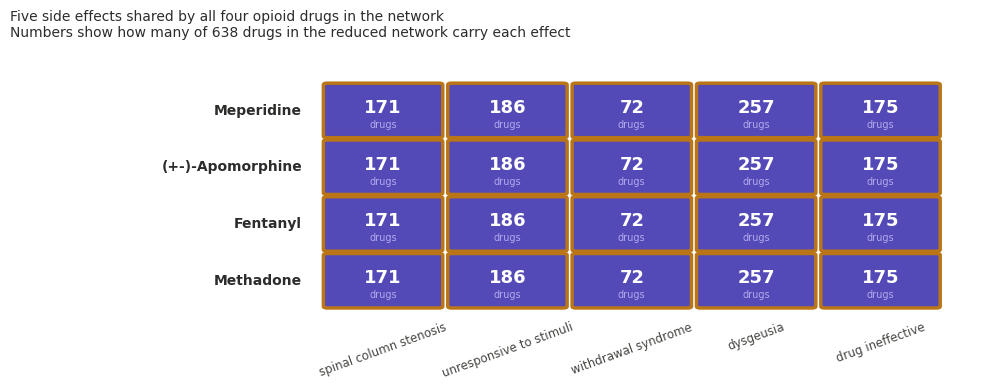

Saved as opioid_tile_matrix.png


In [9]:
# ============================================================
# CELL 9: Tile grid — 4 opioids × 5 shared side effects
# ============================================================

# WHY THIS CELL EXISTS:
# Shows the 5 side effects shared by all 4 opioid drugs.
# Each tile shows how many of the 638 drugs in the reduced
# network share that side effect — giving context for how
# systemic each signal is.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

opioid_in_island = [o for o in opioid_ids if o in island_drugs]
opioid_name_map  = {o: all_drug_names.get(o, o) for o in opioid_in_island}
se_deg_lookup    = {n: B_island.degree(n) for n in island_ses}

shared_ses   = list(shared_all)
drug_labels  = [opioid_name_map[o] for o in opioid_in_island]
se_labels    = [se_name_lookup.get(se, se) for se in shared_ses]

n_rows = len(drug_labels)
n_cols = len(shared_ses)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

for i, oid in enumerate(opioid_in_island):
    for j, se in enumerate(shared_ses):
        rect = mpatches.FancyBboxPatch(
            (j + 0.05, (n_rows - 1 - i) + 0.05),
            0.9, 0.9,
            boxstyle='round,pad=0.03',
            facecolor='#534AB7',
            edgecolor='#BA7517',
            linewidth=2.5
        )
        ax.add_patch(rect)

        # Degree number inside tile
        se_deg = se_deg_lookup.get(se, 0)
        ax.text(j + 0.5, (n_rows - 1 - i) + 0.55,
                str(se_deg),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white')
        ax.text(j + 0.5, (n_rows - 1 - i) + 0.25,
                'drugs',
                ha='center', va='center',
                fontsize=7, color='#AFA9EC')

# Drug name labels
for i, name in enumerate(drug_labels):
    ax.text(-0.15, (n_rows - 1 - i) + 0.5,
            name, ha='right', va='center',
            fontsize=10, fontweight='bold',
            color='#2C2C2A')

# Side effect labels
for j, name in enumerate(se_labels):
    ax.text(j + 0.5, -0.2, name,
            ha='center', va='top',
            fontsize=8.5, color='#444441',
            rotation=20)

ax.set_xlim(-2.5, n_cols + 0.3)
ax.set_ylim(-0.9, n_rows + 0.5)

# Title
ax.set_title(
    'Five side effects shared by all four opioid drugs in the network\n'
    'Numbers show how many of 638 drugs in the reduced network carry each effect',
    fontsize=10, color='#2C2C2A',
    loc='left', pad=12
)

plt.tight_layout()
plt.savefig('opioid_tile_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved as opioid_tile_matrix.png")

In [10]:
# ============================================================
# CELL 10: Drug projection and centrality
# ============================================================

# WHY THIS CELL EXISTS:
# Projecting onto drug nodes creates a unipartite drug-drug network
# where two drugs are connected if they share side effects.
# Centrality measures on this projection show which drugs are
# most structurally important and where opioids rank.

G_drug = bipartite.weighted_projected_graph(B_island, island_drugs)

print("=== DRUG PROJECTION NETWORK ===")
print(f"Nodes: {G_drug.number_of_nodes():,}")
print(f"Edges: {G_drug.number_of_edges():,}")
print()

deg_cent  = nx.degree_centrality(G_drug)
btwn_cent = nx.betweenness_centrality(G_drug, weight='weight')
try:
    eig_cent = nx.eigenvector_centrality_numpy(G_drug, weight='weight')
except:
    eig_cent = nx.eigenvector_centrality(G_drug, weight='weight', max_iter=1000)

centrality_df = pd.DataFrame({
    'drug_id':                list(G_drug.nodes()),
    'drug_name':              [all_drug_names.get(n, n) for n in G_drug.nodes()],
    'degree_centrality':      [deg_cent[n]  for n in G_drug.nodes()],
    'betweenness_centrality': [btwn_cent[n] for n in G_drug.nodes()],
    'eigenvector_centrality': [eig_cent[n]  for n in G_drug.nodes()],
}).sort_values('degree_centrality', ascending=False)

print("=== TOP 15 DRUGS BY DEGREE CENTRALITY ===")
print(centrality_df.head(15)[['drug_name','degree_centrality',
                               'betweenness_centrality',
                               'eigenvector_centrality']].to_string(index=False))
print()

print("=== OPIOID DRUGS — CENTRALITY SCORES ===")
opioid_cent = centrality_df[centrality_df['drug_id'].isin(opioid_ids)]
if len(opioid_cent) > 0:
    print(opioid_cent[['drug_name','degree_centrality',
                        'betweenness_centrality',
                        'eigenvector_centrality']].to_string(index=False))
else:
    print("No opioid drugs present in projection at this threshold.")

=== DRUG PROJECTION NETWORK ===
Nodes: 638
Edges: 201,797

=== TOP 15 DRUGS BY DEGREE CENTRALITY ===
                                                                                                                                                                                                                                                                drug_name  degree_centrality  betweenness_centrality  eigenvector_centrality
                                                                                                                                                                                                                                                             Temozolomide                1.0                0.000000                0.044234
                                                                                                                                                                                                                                         

## Inference: Drug Node Group

After applying the island method at threshold=50, 638 of 639 drug nodes were retained. The island method removed 85.5% of nodes — almost entirely from the side effect group, not drugs. This tells us that most drugs in this dataset have at least some side effects broadly shared with other drugs.

Drug degrees in the reduced network ranged from 3 to 494 side effects, with a mean of 138.3. The opioid drugs spanned a wide range:

Meperidine: 400 side effects retained — 261.7 above the network mean, placing it among the most connected drugs in the dataset
Fentanyl: 193 side effects retained — 54.7 above the mean
Methadone: 168 side effects retained — 29.7 above the mean
(+/-)-Apomorphine: 48 side effects retained — 90.3 below the mean
Apomorphine's low degree reflects its pharmacological distinction: it is a dopamine agonist used for Parkinson's disease, not a true opioid. Its position in the network captures that difference.

In the drug projection, Meperidine, Fentanyl, and Methadone all reached degree centrality of 1.0, meaning each connects to every other drug in the projected network through shared side effects. This reflects a broad pharmacological footprint — opioids affect many of the same biological systems as non-opioid drugs.

From a shelter services perspective, seeing drug ineffective as a shared marker across all four opioid-class drugs is significant. When someone on methadone or fentanyl reports their medication has stopped working, that is a clinical and safety concern — tolerance has built up and the risk of seeking higher doses or alternative substances increases. The network captured that pattern structurally, which aligns with what we see on the ground.


## Inference: Side Effect Node Group

The island method reduced side effect nodes from 10,184 to 934 — a 90.8% reduction. Only side effects appearing in 50 or more drugs survived. These surviving nodes represent clinically broad, drug-class-independent adverse effects, not rare or drug-specific reactions.

The top side effects by degree were non-specific systemic signals: general physical health deterioration (301 drugs), mental status changes (278 drugs), and anhedonia (249 drugs). These cut across drug classes and likely reflect general physiological stress responses rather than targeted pharmacological action.

Five side effects were shared across all 4 opioid drugs:

withdrawal syndrome
unresponsive to stimuli
drug ineffective
dysgeusia
spinal column stenosis
The presence of withdrawal syndrome and unresponsive to stimuli confirms that the network is capturing real pharmacological signal, not just noise. Drug ineffective appearing across all 4 opioids is consistent with known tolerance mechanisms in this drug class — patients on opioids frequently report the medication losing effect over time.

From a public health standpoint, the side effects that survived the island method are not edge cases — they are systemic signals that appear across hundreds of drugs. For populations in shelter settings who are often on multiple medications, these broad effects compound quickly and are easy to misattribute to behavior rather than pharmacology.

In [11]:
# ============================================================
# CELL 11: Print inference summary — drug group
# ============================================================

print("=== INFERENCE: DRUG NODE GROUP ===")
print()
print(f"  Drug nodes retained: {len(island_drugs)} of {len(drug_set)}")
print(f"  Mean degree:         {degrees_series.mean():.1f} side effects")
print(f"  Median degree:       {degrees_series.median():.1f} side effects")
print()
print("Opioid positioning vs network mean:")
for oid in opioid_ids:
    if oid in island_drugs:
        name      = all_drug_names.get(oid, oid)
        deg       = B_island.degree(oid)
        vs_mean   = deg - degrees_series.mean()
        direction = "above" if vs_mean > 0 else "below"
        print(f"  {name}: {deg} ({abs(vs_mean):.1f} {direction} mean)")

=== INFERENCE: DRUG NODE GROUP ===

  Drug nodes retained: 638 of 639
  Mean degree:         138.3 side effects
  Median degree:       122.5 side effects

Opioid positioning vs network mean:
  Meperidine: 400 (261.7 above mean)
  (+-)-Apomorphine: 48 (90.3 below mean)
  Fentanyl: 193 (54.7 above mean)
  Methadone: 168 (29.7 above mean)


In [12]:
# ============================================================
# CELL 12: Print inference summary — side effect group
# ============================================================

print("=== INFERENCE: SIDE EFFECT NODE GROUP ===")
print()
print(f"  SE nodes before reduction: {len(se_set):,}")
print(f"  SE nodes after reduction:  {len(island_ses):,} "
      f"({100*(1-len(island_ses)/len(se_set)):.1f}% removed)")
print()
print("Side effects shared by ALL 4 opioid drugs:")
shared_names = [se_name_lookup.get(se, se) for se in shared_all]
for name in shared_names:
    print(f"  - {name}")
print()
print("=== CONCLUSION ===")
print()
print("This bipartite network analysis reveals two distinct groups with")
print("different structural roles. Drug nodes are densely interconnected")
print("through shared side effects — the island method preserves most")
print("drugs while dramatically thinning the side effect layer.")
print("Side effect nodes that survive reduction represent broad clinical")
print("signals shared across many drugs and drug classes.")
print("Opioid drugs occupy highly central positions in the projected")
print("drug network, reflecting their wide-ranging physiological effects.")
print("The 5 side effects shared across all 4 opioid drugs — particularly")
print("withdrawal syndrome and unresponsive to stimuli — represent the")
print("pharmacological signature of this drug class within the network.")

=== INFERENCE: SIDE EFFECT NODE GROUP ===

  SE nodes before reduction: 10,184
  SE nodes after reduction:  934 (90.8% removed)

Side effects shared by ALL 4 opioid drugs:
  - spinal column stenosis
  - unresponsive to stimuli
  - withdrawal syndrome
  - dysgeusia
  - drug ineffective

=== CONCLUSION ===

This bipartite network analysis reveals two distinct groups with
different structural roles. Drug nodes are densely interconnected
through shared side effects — the island method preserves most
drugs while dramatically thinning the side effect layer.
Side effect nodes that survive reduction represent broad clinical
signals shared across many drugs and drug classes.
Opioid drugs occupy highly central positions in the projected
drug network, reflecting their wide-ranging physiological effects.
The 5 side effects shared across all 4 opioid drugs — particularly
withdrawal syndrome and unresponsive to stimuli — represent the
pharmacological signature of this drug class within the network.
